%

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
%matplotlib inline

%% Read dataset from previous lab

In [2]:
df = pd.read_csv("data/dataset_part2.csv")

If you were unable to complete the previous lab correctly you can uncomment and load this csv<br>
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     str    
 2   BoosterVersion  90 non-null     str    
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     str    
 5   LaunchSite      90 non-null     str    
 6   Outcome         90 non-null     str    
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     str    
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     str    
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
 17  Class           90 non-null     int64  
dtypes: 

None

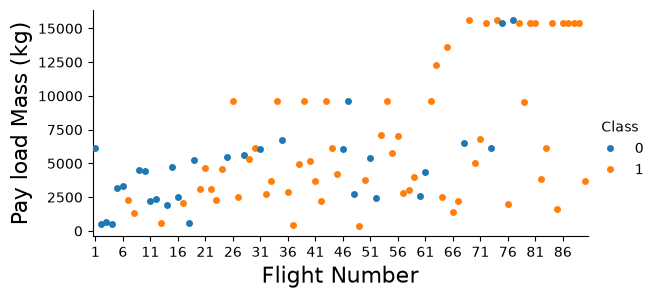

In [3]:
display(df.info())
# %% Plot relation between payload mass and flight number
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class",
             data=df, height=3, aspect =2)
plt.xlabel("Flight Number",fontsize=16)
plt.xticks(ticks=df.index[0::5], labels=df.FlightNumber[0::5])
plt.ylabel("Pay load Mass (kg)",fontsize=16)
plt.show()

%% Plot relationship between Flight Number and Launch Site

Text(0.5, 1.0, 'Flight No. vs Launch Site\n considering booster landing success')

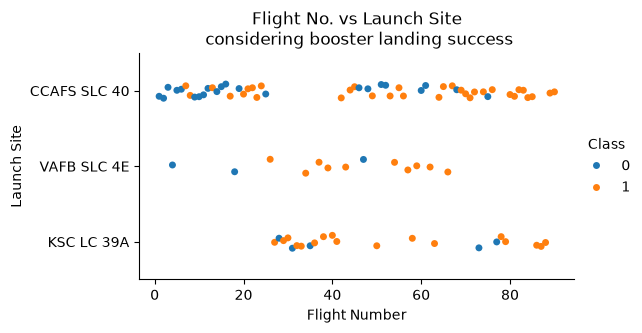

In [4]:
sns.catplot(x='FlightNumber', y='LaunchSite', hue='Class',
            data=df, height=3, aspect =2)
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.title('Flight No. vs Launch Site\n considering booster landing success')

%% Plot relationship between Payload Mass and Launch Site

Text(0.5, 1.0, 'Payload Mass. vs Launch Site\n considering booster landing success')

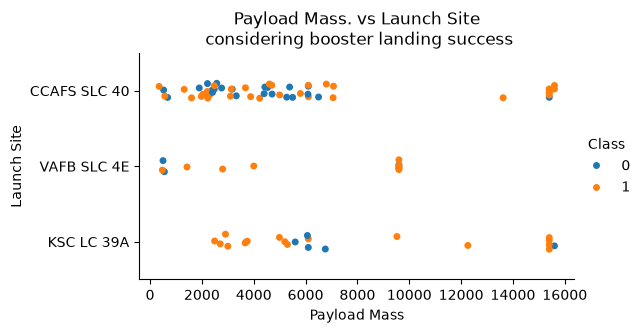

In [5]:
sns.catplot(x='PayloadMass', y='LaunchSite', hue='Class',
            data=df, height=3, aspect =2)
plt.xlabel('Payload Mass')
plt.ylabel('Launch Site')
plt.title('Payload Mass. vs Launch Site\n considering booster landing success')

%% Plot relationship between success rate of each orbit type

,Orbit,Class
8,SO,0.000000
2,GTO,0.518519
4,ISS,0.619048
6,MEO,0.666667
7,PO,0.666667
5,LEO,0.714286
10,VLEO,0.857143
3,HEO,1.000000
1,GEO,1.000000
0,ES-L1,1.000000


Text(0.5, 0, 'Orbit type')

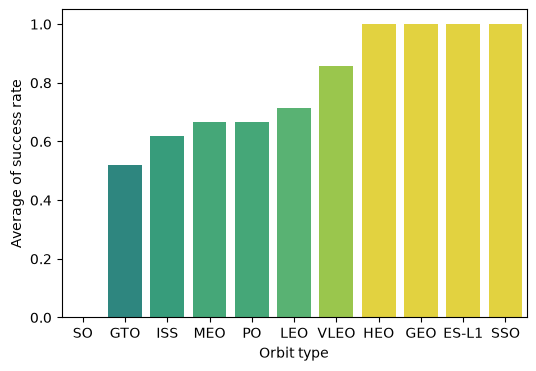

In [6]:
df_orbit = df.groupby('Orbit', as_index=False)[['Class']].mean()
df_orbit.sort_values('Class', inplace=True)
display(df_orbit)
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x='Orbit', y='Class', hue='Class', legend=False,
            palette='viridis', data=df_orbit, ax=ax, 
            err_kws={'color':'r'})
plt.ylabel('Average of success rate')
plt.xlabel('Orbit type')

%% Plot relationship between Flight No. and Orbit type

Text(0.5, 1.0, 'Flight No. vs Orbit type\n considering booster landing success')

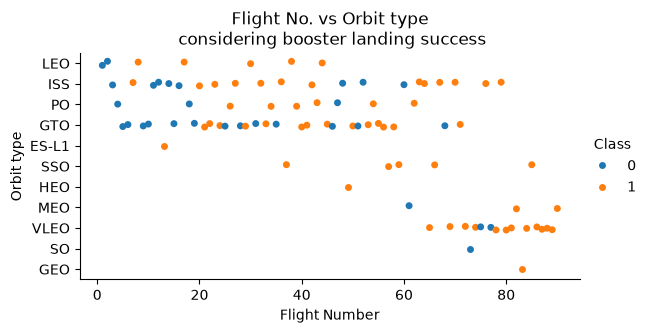

In [7]:
sns.catplot(y='Orbit', x='FlightNumber', hue='Class',
            data=df, height=3, aspect =2)
plt.xlabel('Flight Number')
plt.ylabel('Orbit type')
plt.title('Flight No. vs Orbit type\n considering booster landing success')

%% Plot relationship between Payload mass and Orbit type

Text(0.5, 1.0, 'Payload mass vs Orbit type\n considering booster landing success')

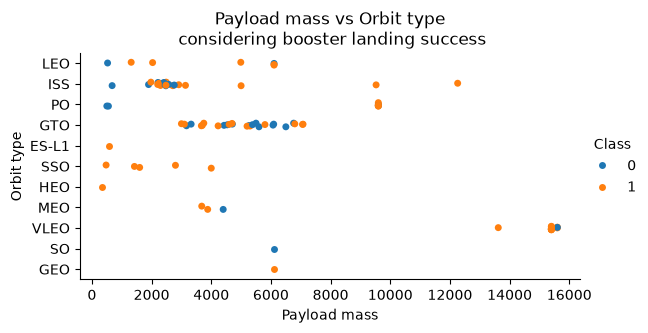

In [8]:
sns.catplot(y='Orbit', x='PayloadMass', hue='Class',
            data=df, height=3, aspect =2)
plt.xlabel('Payload mass')
plt.ylabel('Orbit type')
plt.title('Payload mass vs Orbit type\n considering booster landing success')

%% Getting year data from dataframe

In [9]:
df['Date'] = pd.to_datetime(df.Date)
df['Year'] = df[['Date']].map(lambda x: x.year)
df_year = df.groupby('Year')[['Class']].mean()

%% Plot relationship between launch years and landing success rate

Text(0.5, 1.0, 'Launch success yearly trend')

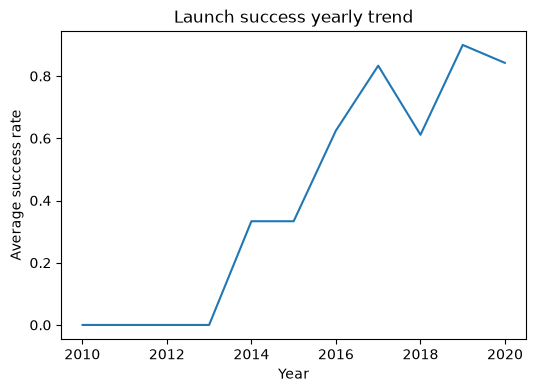

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
sns.set_theme(style='darkgrid',)
sns.lineplot(x='Year', y='Class', data=df_year, ax=ax)
plt.xlabel('Year')
plt.ylabel('Average success rate')
plt.title('Launch success yearly trend')

%% Selecting features for success prediction

In [11]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 
               'LaunchSite', 'Flights', 'GridFins', 'Reused',
                 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()
# %% Separating columns by type
numerical_cols = features.select_dtypes(['int','float','bool'])
categorical_cols = features.select_dtypes(['object', 'string', ])
display(numerical_cols,
categorical_cols)
# %% Create dummy variables to categorical columns
features_one_hot = pd.concat([numerical_cols, 
                             pd.get_dummies(categorical_cols) ],
                             axis=1)
features_one_hot = features_one_hot.astype('float64')
# %% Export as CSV
features_one_hot.to_csv('dataset_part3.csv', index=False)

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount
0,1,6104.959412,1,False,False,False,1.0,0
1,2,525.000000,1,False,False,False,1.0,0
2,3,677.000000,1,False,False,False,1.0,0
3,4,500.000000,1,False,False,False,1.0,0
4,5,3170.000000,1,False,False,False,1.0,0
...,...,...,...,...,...,...,...,...
85,86,15400.000000,2,True,True,True,5.0,2
86,87,15400.000000,3,True,True,True,5.0,2
87,88,15400.000000,6,True,True,True,5.0,5
88,89,15400.000000,3,True,True,True,5.0,2


,Orbit,LaunchSite,LandingPad,Serial
0,LEO,CCAFS SLC 40,NaN,B0003
1,LEO,CCAFS SLC 40,NaN,B0005
2,ISS,CCAFS SLC 40,NaN,B0007
3,PO,VAFB SLC 4E,NaN,B1003
4,GTO,CCAFS SLC 40,NaN,B1004
...,...,...,...,...
85,VLEO,KSC LC 39A,5e9e3032383ecb6bb234e7ca,B1060
86,VLEO,KSC LC 39A,5e9e3032383ecb6bb234e7ca,B1058
87,VLEO,KSC LC 39A,5e9e3032383ecb6bb234e7ca,B1051
88,VLEO,CCAFS SLC 40,5e9e3033383ecbb9e534e7cc,B1060


%%